# Customer Feedback Analysis and Automated Response

**Hiral Sarkar** &nbsp;·&nbsp; Imarticus Data Science Internship (Python Foundations & Gen AI)

A retailer gets thousands of customer reviews a week. Right now someone on the support team
reads through all of them by hand, picks out the angry ones, and writes back an apology to
each. That is slow, and the reviews that most need a reply are the easiest to lose in the pile.

So the plan for this notebook is fairly simple:

1. **Clean up** the review data so it is actually usable.
2. **Find the critical reviews** (the 1 and 2 star ones) with plain rules, no machine learning, since the brief specifically asks for that.
3. **Work out what people actually complain about** by counting words and phrases.
4. **Draft replies automatically** for the most urgent ones using a language model.

I am using the *Women's Clothing E-Commerce Reviews* dataset (about 23k reviews). The reply
emails need a shop name to sign off with, so I am calling it **StyleNest**.

## 1. Getting set up (Data Loading)

`pandas` for the data, `matplotlib` for a few charts, `Counter`
for word counting, and `requests` for the API call near the end.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt                  
import re                                        # clean text (regex)                                       
import requests                                  # OpenRouter API call
import time                                      # wait between API retries
from collections import Counter                  # word & phrase counts
from IPython.display import Markdown, display    # emails (replies)

In [2]:
df = pd.read_csv("Womens Clothing E-Commerce Reviews.csv", index_col=0)
print("Shape:", df.shape)
df

Shape: (23486, 10)


,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses
...,...,...,...,...,...,...,...,...,...,...
23481,1104,34,Great dress for many occasions,I was very happy to snag this dress at such a ...,5,1,0,General Petite,Dresses,Dresses
23482,862,48,Wish it was made of cotton,"It reminds me of maternity clothes. soft, stre...",3,1,0,General Petite,Tops,Knits
23483,1104,31,"Cute, but see through","This fit well, but the top was very see throug...",3,0,1,General Petite,Dresses,Dresses
23484,1084,28,"Very cute dress, perfect for summer parties an...",I bought this dress for a wedding i have this ...,3,1,2,General,Dresses,Dresses


## 2. Cleaning the data

First question before anything else: what is missing?

In [3]:
df.isnull().sum()

Clothing ID                   0
Age                           0
Title                      3810
Review Text                 845
Rating                        0
Recommended IND               0
Positive Feedback Count       0
Division Name                14
Department Name              14
Class Name                   14
dtype: int64

A few gaps. Here is how I am treating each one, and why:

- **Review Text (845 missing)** is the whole point of the project, so a review with no text
  is useless to me. I drop those rows.
- **Title (3,810 missing)** is just a headline, and plenty of perfectly good reviews do not
  have one. I keep those rows and fill the blank with an empty string.
- **Division / Department / Class Name (14 each)** is tiny, but I fill them with `"Unknown"`
  so they do not quietly vanish from the charts later.

I print the number of rows I am dropping so I know exactly how much data I am giving up.

In [4]:
# The only column I really need is the review text, so I drop the rows missing it.
df = df.dropna(subset=["Review Text"]).reset_index(drop=True)
print(f"{len(df):,} reviews left.")

df["Title"] = df["Title"].fillna("")
for col in ["Division Name", "Department Name", "Class Name"]:
    df[col] = df[col].fillna("Unknown")

22,641 reviews left.


### Cleaning the review text

For the word counting later I want everything lowercased and stripped of punctuation and
numbers, so that "Great!" and "great" get counted as the same word. I keep the original
column untouched and put the cleaned version in a new one, because I will want the real
wording back when I generate the reply emails.

In [5]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", " ", text)     # drop any stray links
    text = re.sub(r"[^a-z\s]", " ", text)    # keep letters and spaces only
    text = re.sub(r"\s+", " ", text)         # tidy up the spacing
    return text.strip()

df["clean_text"] = df["Review Text"].apply(clean_text)

# quick sanity check on one review
print("Before:", df["Review Text"].iloc[45][:350])
print("------------------------------------------")
print("After: ", df["clean_text"].iloc[45][:350])

Before: I bought this item from online... the fit on the model looked a little loose but when i got mine it seemed a bit tight! so i took it back to the store & ordered a larger size. for the sale price this is a great top.
------------------------------------------
After:  i bought this item from online the fit on the model looked a little loose but when i got mine it seemed a bit tight so i took it back to the store ordered a larger size for the sale price this is a great top


## 3. A first look at the reviews

Before I filter anything, I want a feel for the data. Two questions: how are the ratings
spread out, and are the bad reviews coming evenly from across the catalogue or piling up in
one place?

### How are the ratings distributed?

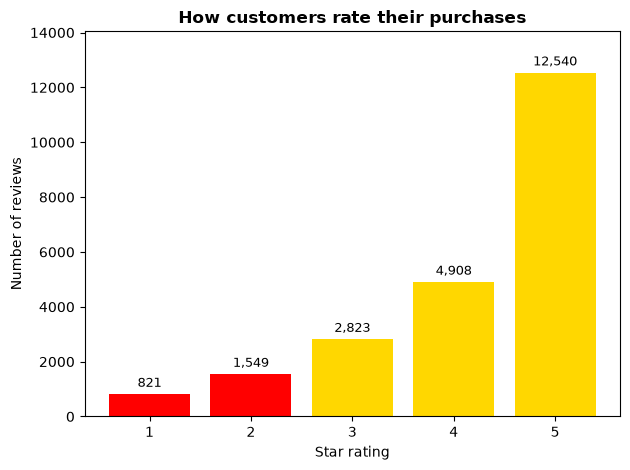

In [6]:
rating_counts = df["Rating"].value_counts().sort_index()

fig, ax = plt.subplots()
bars = ax.bar(rating_counts.index, rating_counts.values,
              color=["red" if r <= 2 else "gold" for r in rating_counts.index])
ax.bar_label(bars, labels=[f"{v:,}" for v in rating_counts.values], padding=3, fontsize=9)
ax.set_title("How customers rate their purchases", fontweight="bold")
ax.set_xlabel("Star rating")
ax.set_ylabel("Number of reviews")
ax.set_ylim(0, rating_counts.max() * 1.12)
plt.tight_layout()
plt.show()

Most people are happy: 4 and 5 stars completely dominate. The 1 and 2 star reviews are
the two red bars, and they are clearly a minority. That is reassuring, because it means the
"critical" pile is small enough to handle with care rather than drown in.

### Are the bad reviews spread evenly across departments?

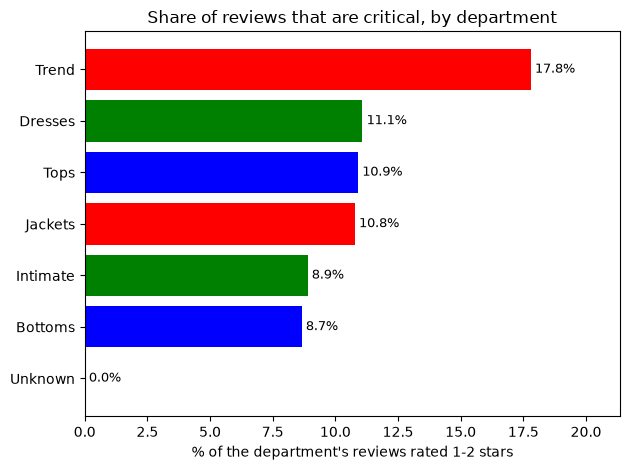

In [7]:
df["is_critical"] = df["Rating"].isin([1, 2])

by_dept = (df.groupby("Department Name")["is_critical"].mean().sort_values()*100)
bars = plt.barh(by_dept.index, by_dept.values, color=["red", "blue", "green"])
plt.bar_label(bars, labels=[f"{v:.1f}%" for v in by_dept.values], padding=3, fontsize=9)
plt.title("Share of reviews that are critical, by department")
plt.xlabel("% of the department's reviews rated 1-2 stars")
plt.xlim(0, by_dept.max() * 1.2)
plt.tight_layout()
plt.show()

The spread is not even. Some departments run noticeably hotter than others. If one product line makes more customers unhappy, that
is where the procurement team should look first.

## 4. Isolating the critical reviews

Here is the core rule, and it is deliberately boring: a review is "critical" if it was rated
1 or 2 stars. No model, no threshold to tune, just a filter. This is the "no machine
learning" part the brief asked for.

In [8]:
critical = df[df["Rating"].isin([1, 2])].copy()
print(f"{len(critical):,} critical reviews "
      f"({len(critical) / len(df) * 100:.1f}% of everything).")
critical[["Rating", "Department Name", "Review Text"]].head()

2,370 critical reviews (10.5% of everything).


,Rating,Department Name,Review Text
5,2,Dresses,"I love tracy reese dresses, but this one is no..."
22,2,Dresses,"First of all, this is not pullover styling. th..."
26,2,Tops,I have been waiting for this sweater coat to s...
33,2,Tops,"I ordered this 3 months ago, and it finally ca..."
56,2,Intimate,I am pregnant and i thought this would be a gr...


## 5. What are people actually complaining about?

A rating tells me a review is bad, but not *why*. To get the why, I count the words that
show up most often across the critical reviews.

Raw word counts are mostly filler ("the", "and", "it"), so I strip those out with a
small stopword list I wrote by hand. My first pass was still full of empty words like "like", "back" and "one",
so I kept growing the list until the words left standing actually meant something. I also
drop a few dataset-specific words, mainly `retailer` (the brand name was anonymised to that
word in the data) and plain garment words like `dress` that are everywhere and say nothing
about the complaint itself.

In [9]:
# A short, hand-written stopword list. Common filler plus a few words that are
# everywhere in this particular dataset and tell me nothing about the complaint.
stopwords = set((
    "a an the this that these those i you he she it we they me my your his her its our their "
    "is am are was were be been being do does did have has had will would can could should "
    "and or but if then so because as of at by for with about to from in on into over under "
    "not no just very really too also more most much many than there here what which who when "
    "where why how all any both each few other some such only own same s t im ive "
    
    # a second pass of empty words that showed up in my first word count
    "like likes back look looks looked looking love loved loves out one ones even way ways "
    "get got want wanted know knew think thought made make making go going went still though "
    "well overall bit little lot around able say said thing things need really them "
    
    # leftover stems after stripping apostrophes (didn't -> didn t, doesn't -> doesn t)
    "didn don doesn wasn weren aren isn wouldn couldn shouldn wont cant dont thats "
    
    # dataset-specific noise
    "retailer dress top shirt fabric size sizes wear worn ordered order review reviews").split())

def top_words(texts, n=20):
    counts = Counter()
    for t in texts:
        for w in t.split():
            if len(w) > 2 and w not in stopwords:
                counts[w] += 1
    return counts.most_common(n)

top_keywords = top_words(critical["clean_text"], n=20)
keywords_df = pd.DataFrame(top_keywords, columns=["word", "count"])
keywords_df

,word,count
0,fit,687
1,small,518
2,material,428
3,color,380
4,quality,339
5,large,302
6,cute,293
7,sweater,276
8,great,268
9,tried,259


### The complaint words, as a chart

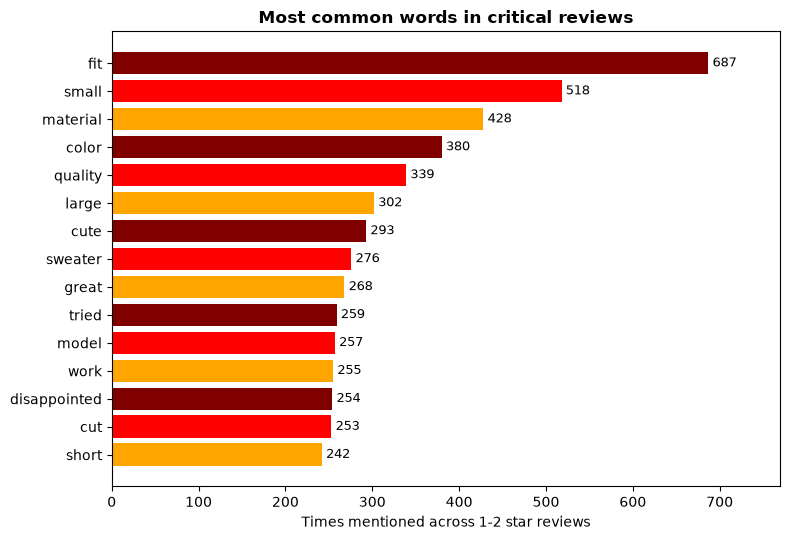

In [10]:
top15 = keywords_df.head(15).iloc[::-1]

fig, ax = plt.subplots(figsize=(8, 5.5))
bars = ax.barh(top15["word"], top15["count"], color=["orange","red","maroon"])
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_title("Most common words in critical reviews", fontweight="bold")
ax.set_xlabel("Times mentioned across 1-2 star reviews")
ax.set_xlim(0, top15["count"].max() * 1.12)
plt.tight_layout()
plt.show()

### Two-word phrases give better context

Single words lose meaning fast. "Small" on its own could be "runs small" or "not small". So
I also counted two-word phrases, and this time I keep the little words like "too" and "not",
because that is exactly where the meaning lives.

In [11]:
phrase_stopwords = stopwords - {"not", "too", "very", "so"}

def top_phrases(texts, n=15):
    counts = Counter()
    for t in texts:
        words = [w for w in t.split() if len(w) > 2 and w not in phrase_stopwords]
        for a, b in zip(words, words[1:]):
            counts[f"{a} {b}"] += 1
    return counts.most_common(n)

phrases_df = pd.DataFrame(top_phrases(critical["clean_text"]), columns=["phrase", "count"])
phrases_df

,phrase,count
0,not flattering,106
1,too big,82
2,very disappointed,73
3,see through,73
4,too short,67
5,too small,60
6,not sure,58
7,too bad,55
8,not worth,50
9,too tight,50


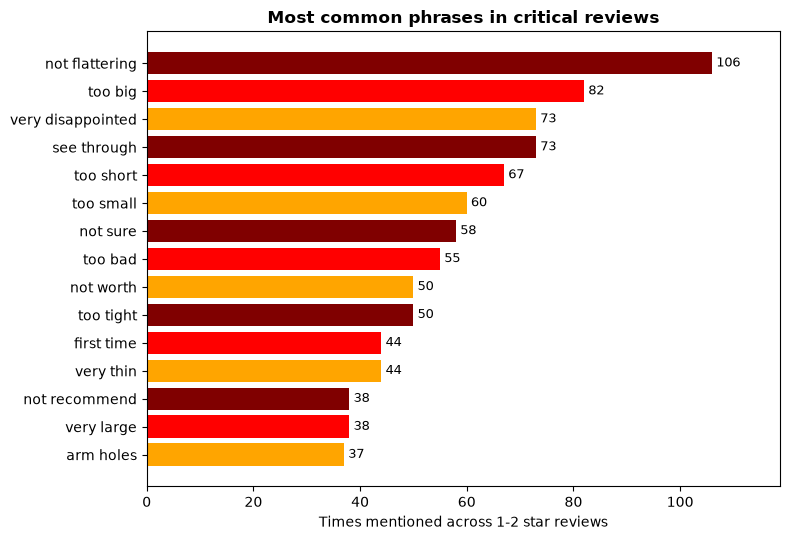

In [12]:
top_ph = phrases_df.head(15).iloc[::-1]

fig, ax = plt.subplots(figsize=(8, 5.5))
bars = ax.barh(top_ph["phrase"], top_ph["count"], color=["orange","red","maroon"])
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_title("Most common phrases in critical reviews", fontweight="bold")
ax.set_xlabel("Times mentioned across 1-2 star reviews")
ax.set_xlim(0, top_ph["count"].max() * 1.12)
plt.tight_layout()
plt.show()

### Grouping the words into themes

Thirty separate words is hard to act on. I was curious whether they would fall into a few
obvious buckets, so I sorted the common complaints into themes by hand and counted how many
critical reviews land in each. A review can count towards more than one theme, which feels
right, since people complain about several things at once.

In [12]:
themes = {
    "Fit & sizing":     ["small", "large", "tight", "loose", "big", "petite",
                         "runs", "fit", "sizing", "boxy", "narrow"],
    "Quality":          ["quality", "cheap", "cheaply", "material", "thin", "flimsy",
                         "poorly", "seam", "seams", "fell", "apart", "itchy"],
    "Look vs. photo":   ["color", "colour", "looked", "picture", "photo",
                         "different", "online", "shape", "weird"],
    "Price":            ["price", "priced", "expensive", "overpriced", "worth", "money"],
    "Shipping":         ["late", "shipping", "delivery", "delayed", "arrived", "package"],
    "Returns/service":  ["return", "returned", "refund", "exchange", "service"],
}

def count_themes(texts, theme_map):
    rows = []
    for name, words in theme_map.items():
        words = set(words)
        hits = sum(any(w in set(t.split()) for w in words) for t in texts)
        rows.append((name, hits, round(hits / len(texts) * 100, 1)))
    return (pd.DataFrame(rows, columns=["theme", "reviews", "%_of_critical"])
              .sort_values("reviews", ascending=False)
              .reset_index(drop=True))

themes_df = count_themes(critical["clean_text"], themes)
themes_df

,theme,reviews,%_of_critical
0,Fit & sizing,1316,55.5
1,Look vs. photo,1069,45.1
2,Quality,936,39.5
3,Returns/service,383,16.2
4,Price,253,10.7
5,Shipping,131,5.5


### The themes, as a chart

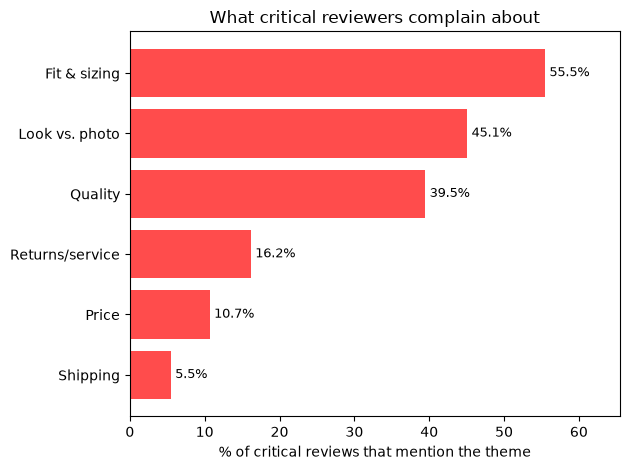

In [13]:
order = themes_df.iloc[::-1]

bars = plt.barh(order["theme"], order["%_of_critical"], color=["red"], alpha = 0.7)
plt.bar_label(bars, labels=[f"{v:.1f}%" for v in order["%_of_critical"]], padding=3, fontsize=9)
plt.title("What critical reviewers complain about")
plt.xlabel("% of critical reviews that mention the theme")
plt.xlim(0, order["%_of_critical"].max() * 1.18)
plt.tight_layout()
plt.show()

Fit and sizing tops the chart, followed by quality. That actually makes sense:
those are the two things you genuinely cannot judge from a product photo, so they are where
online clothing disappoints people most.

## 6. Which reviews should we reply to first?

I cannot hand-write replies to all of these, and the point is to prioritise. Not every
1-star review is equally urgent. I want the ones that are:

- the lowest rated (1 star),
- detailed enough that there is a real, specific complaint to answer, and
- upvoted by other shoppers, because a complaint lots of people agreed with does the most
  damage if it is left sitting there.

So I take the 1-star reviews, keep the reasonably long ones, and sort by how many "positive
feedback" votes they picked up.

In [14]:
detailed = critical[(critical["Rating"] == 1) & (critical["Review Text"].str.len() > 250)]

top3 = detailed.sort_values("Positive Feedback Count", ascending=False).head(3)
top3[["Positive Feedback Count", "Department Name", "Review Text"]]

,Positive Feedback Count,Department Name,Review Text
7493,108,Jackets,"I generally don't write bad reviews, but there..."
17839,48,Dresses,Do not buy this dress for full price. the desi...
12061,43,Tops,"There were no reviews, it's an ""online exclusi..."


## 7. Drafting the replies with an LLM

Now the Gen AI part. For each of those three reviews I ask a model to write a short, actually
apologetic reply that names the customer's specific problem and signs off from StyleNest.

I am using **OpenRouter**, which lets me reach a lot of models through one endpoint and I am using a free one. 
The key just goes in a plain variable below.

In [15]:
API_KEY = "PASTE-YOUR-OPENROUTER-KEY-HERE"   # OpenRouter, free tier

# The free models get busy and throw rate-limit errors, so I keep a few and try each.
MODELS = ["google/gemma-4-26b-a4b-it:free", "meta-llama/llama-3.3-70b-instruct:free", "qwen/qwen3-next-80b-a3b-instruct:free", "google/gemma-4-31b-it:free", "meta-llama/llama-3.2-3b-instruct:free",]

Most of the quality comes from the prompt. I tell the model who it is, ask it to name
the specific problem instead of a vague "sorry for your experience", and to offer one real
next step. I also tell it not to invent order numbers, because models love making those up.

In [16]:
def write_reply(review_text):
    system = (
        "You are Sunaina, a friendly customer support agent at StyleNest, an online "
        "women's clothing shop. A customer left an unhappy review. Write a short apology "
        "email of about 120-150 words that opens with real empathy, names the specific "
        "problem the customer mentioned, takes responsibility without excuses and offers "
        "one clear next step (a refund or a replacement). Keep it warm and human, no "
        "corporate jargon and do not invent order numbers. Start with a 'Subject:' line "
        "and sign off as Sunaina, Customer Care, StyleNest.")
    payload = {"messages": [{"role": "system", "content": system}, {"role": "user", "content": f'The review:\n"{review_text}"'},],
               "temperature": 0.7,}
    
    # try each model and if they are all busy wait a moment then go for round two again
    for _ in range(8):
        for model in MODELS:
            r = requests.post("https://openrouter.ai/api/v1/chat/completions",
                              headers={"Authorization": f"Bearer {API_KEY}"},
                              json={**payload, "model": model}, timeout=60,)
            if r.status_code == 200 and "choices" in r.json():
                return r.json()["choices"][0]["message"]["content"].strip(), model
        time.sleep(8)
    raise RuntimeError("Every free model is rate-limited right now. Try again in a minute.")

And now the actual run: we feed three reviews in and expect three drafted replies as the output.

In [17]:
drafts = []
for i, (_, row) in enumerate(top3.iterrows(), start=1):
    reply, model = write_reply(row["Review Text"])
    drafts.append({"n": i, "department": row["Department Name"],
                   "review": row["Review Text"], "model": model, "reply": reply})
    display(Markdown(
        f"### Email {i}\n"
        f"*{row['Department Name']} &nbsp;·&nbsp; drafted by* `{model}`\n\n"
        f"**Original review**\n\n> {row['Review Text']}\n\n"
        f"**Drafted reply**\n\n{reply}\n\n---"))

### Email 1
*Jackets &nbsp;·&nbsp; drafted by* `google/gemma-4-26b-a4b-it:free`

**Original review**

> I generally don't write bad reviews, but there is a real discrepancy between the quality of this kimono and the cost. the design and colors are great, but the fabric is ripping on all the kimonos on the rack in my store where the manufacturer's tag is at the back of the neck. the material is very thin, so there are other small holes beginning throughout the garment. i shop at retailer all the time, and this is not a $98 item of clothing.

**Drafted reply**

Subject: We’re so sorry about your kimono

Hi there,

I am truly sorry to hear about the experience you’ve had with your recent purchase. I can completely understand your frustration; when you invest $98 in a beautiful piece, you expect it to feel substantial and last much longer than a few wears. It’s incredibly disappointing to hear that the fabric is ripping near the tag and developing holes so quickly.

Please know that this is not the standard of quality we strive for at StyleNest, and I take full responsibility for letting you down this time. We clearly missed the mark on the durability of this material.

I want to make this right immediately. Would you prefer a full refund to your original payment method, or should I send out a replacement from a different batch? Just let me know your preference.

Warmly,

Sunaina, Customer Care, StyleNest

---

### Email 2
*Dresses &nbsp;·&nbsp; drafted by* `google/gemma-4-26b-a4b-it:free`

**Original review**

> Do not buy this dress for full price. the design looks great but after receiving the dress, the material is made of extremely cheap slinky-ish polyester that you would find at a f21 store. the stitching is horrific and created an uneven "hump" on the back seam. just absolutely poor poor quality.

**Drafted reply**

Subject: So sorry about your recent dress order

Hi there,

I was so incredibly sorry to read your review. I can hear how disappointing it was to receive a dress that looked beautiful online, only to have the actual material feel cheap and the stitching arrive so poorly constructed. That is definitely not the quality we want you to experience when shopping with us, and I truly apologize for letting you down.

Please know that we take full responsibility for this; we clearly missed the mark on our quality control for this item. I want to make this right for you immediately. Would you prefer a full refund to your original payment method, or would you like us to send out a replacement after a manual quality inspection?

Just reply to this email with your preference, and I will take care of it right away.

Warmly,

Sunaina, Customer Care, StyleNest

---

### Email 3
*Tops &nbsp;·&nbsp; drafted by* `google/gemma-4-26b-a4b-it:free`

**Original review**

> There were no reviews, it's an "online exclusive" and thought it might look good with a nice skirt at an upcoming wedding. the spandex jersey back looks like sweat shirt material. on the white version of this, it is mismatched with an oatmeal color and white that just looks awful. as a busty 36d i was stunned to find myself swimming in a medium. it does not look like the photograph and the sleeve billow out. i feel like this had to have been clipped and tucked in for this photograph. i'm an anth

**Drafted reply**

Subject: We're so sorry about your recent order

Hi there,

I am so incredibly sorry that the top you ordered for your upcoming wedding wasn't what you expected. Reading your review, I can truly sense your disappointment, especially since you were looking forward to styling it for such a special occasion.

It sounds like the fabric quality wasn't as described, the colors were mismatched, and most importantly, the fit was much larger and looser than the photos suggested. You are absolutely right—the photos should accurately represent how the garment sits on a real person, and we clearly missed the mark here.

I want to make this right immediately. Would you prefer a full refund to your original payment method, or would you like us to send out a replacement in a different size? Please just let me know which you'd prefer.

Warmly,

Sunaina
Customer Care, StyleNest

---

In [18]:
# Save each drafted reply as a Word document in an emails/ folder.
from docx import Document
import os

os.makedirs("emails", exist_ok=True)
for d in drafts:
    doc = Document()
    doc.add_heading(f"StyleNest Customer Care - Email {d['n']}", level=1)
    doc.add_paragraph(f"Department: {d['department']}    Drafted by: {d['model']}").runs[0].italic = True
    doc.add_paragraph("Original review:").runs[0].bold = True
    doc.add_paragraph(d["review"]).runs[0].italic = True
    doc.add_paragraph("")
    for line in d["reply"].splitlines():
        line = line.strip()
        if not line:
            continue
        para = doc.add_paragraph(line)
        if line.lower().startswith("subject:"):
            para.runs[0].bold = True
    name = f"emails/Email_{d['n']}_{d['department'].replace('/', '-')}.docx"
    doc.save(name)
    print("Saved", name)

Saved emails/Email_1_Jackets.docx
Saved emails/Email_2_Dresses.docx
Saved emails/Email_3_Tops.docx


## 8. What I found (Key Insights)

A few things stood out to me:

- Only about **1 in 10** reviews is critical, so automating just that slice is realistic.
  The team can keep replying by hand everywhere the tone is already positive.

- The complaints are not random noise. They cluster hard around **fit/sizing** and
  **quality**, which are exactly the two things you cannot judge from a photo.

- The three drafted replies came out genuinely specific. They mention the real problem
  rather than a generic apology, so with a human giving each one a quick read before it
  goes out, this would cut a lot of writing the email from scratch that the support team does today.

---

Thanks for reading. - Hiral Sarkar.